# Hyperparameter Black-Scholes
## Lambda

In [9]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools
import seaborn as sns

### Colab Setup

In [10]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.33 KiB | 52.00 KiB/s, done.
From https://github.com/egil10/fys5429
   95b4c53..ffbcd04  main       -> origin/main
Updating 95b4c53..ffbcd04
Fast-forward
 code/notebooks/hyper_bs_2_lr.ipynb     |  12 ---
 code/notebooks/hyper_bs_3_lambda.ipynb | 155 +++++++++------------------------
 2 files changed, 43 insertions(+), 124 deletions(-)
Working directory: /content/fys5429/code/notebooks


### Paths

In [11]:
data_path = Path("..") / "data" / "generated" / "bs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [12]:
import sys
sys.path.insert(0, "../scripts")
from bspinn import BSPINN
from train_bs import train_pinn

### Global parameters

In [13]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics (Analytical Benchmarks)
K = 100.0
r = 0.05
sigma = 0.20
T_max = 1.0
S_max = 300.0

# NN
HIDDEN_LAYERS = 2
NEURONS_PER_LAYER = 256
LEARNING_RATE = 5e-4

# Training
PRINT_ROWS = 20

# PINN Loss Weights
LAMBDA_PDE = 5.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

# Epochs and sweeps
LAMBDA_PDE_VALUES = [10.0, 15.0, 20.0, 25.0, 30.0]
LAMBDA_IC_VALUES  = [5.0, 10.0, 15.0, 20.0]
LAMBDA_BC_FIXED   = 5.0
SWEEP_EPOCHS      = 5000

Using device: cuda


### Reading Data

In [14]:
# Check if data exists and has the right S range, otherwise regenerate
if data_path.exists():
    df_all = pd.read_parquet(data_path)
    s_range = df_all['S'].max()
    if s_range < S_max * 0.9:
        print(f"Existing data has S_max={s_range:.0f}, expected ~{S_max:.0f}. Regenerating...")
        data_path.unlink()

if not data_path.exists():
    print(f"Generating collocation data with S_max={S_max}, T_max={T_max}...")

    N_INTERIOR = 2000
    N_BOUNDARY = 500

    S_interior = torch.rand(N_INTERIOR, 1) * S_max
    tau_interior = torch.rand(N_INTERIOR, 1) * T_max

    S_ic_gen = torch.rand(N_BOUNDARY, 1) * S_max
    tau_ic_gen = torch.zeros(N_BOUNDARY, 1)

    S_bc_gen = torch.zeros(N_BOUNDARY, 1)
    tau_bc_gen = torch.rand(N_BOUNDARY, 1) * T_max

    df_all = pd.concat([
        pd.DataFrame({'S': S_interior.numpy().flatten(),
                       'tau': tau_interior.numpy().flatten(),
                       'point_type': 'interior'}),
        pd.DataFrame({'S': S_ic_gen.numpy().flatten(),
                       'tau': tau_ic_gen.numpy().flatten(),
                       'point_type': 'initial_condition'}),
        pd.DataFrame({'S': S_bc_gen.numpy().flatten(),
                       'tau': tau_bc_gen.numpy().flatten(),
                       'point_type': 'boundary_condition'}),
    ], ignore_index=True)

    data_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(data_path)
    print(f"Saved to {data_path}")
else:
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")

Loaded existing data from ../data/generated/bs_collocation.parquet (S_max=300)
Interior points: 2000
IC points:       500
BC points:       500


### Lambda Sweep

In [15]:
sweep_results = []
start_time = time.time()
total_runs = len(LAMBDA_PDE_VALUES) * len(LAMBDA_IC_VALUES)

header = f"{'#':>3} | {'λ_PDE':>6} {'λ_IC':>6} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, (lam_pde, lam_ic) in enumerate(itertools.product(LAMBDA_PDE_VALUES, LAMBDA_IC_VALUES)):

    run_start = time.time()
    result = train_pinn(S_in, tau_in, S_ic, tau_ic, S_bc, tau_bc,
                    sigma, r, K, device,
                    lam_pde, lam_ic, LAMBDA_BC_FIXED, SWEEP_EPOCHS,
                    lr=LEARNING_RATE, hidden_layers=HIDDEN_LAYERS,
                    neurons=NEURONS_PER_LAYER, activation='tanh')

    result['lambda_pde'] = lam_pde
    result['lambda_ic'] = lam_ic
    result['lambda_bc'] = LAMBDA_BC_FIXED
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {lam_pde:>6.1f} {lam_ic:>6.1f} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")

  # |  λ_PDE   λ_IC |     PDE Loss      IC Loss      BC Loss |   Time      ETA
──────────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  1 |   10.0    5.0 |     0.004268     0.060933     0.000549 |    53s   1003s
  2 |   10.0   10.0 |     0.005313     0.033554     0.000761 |    46s    889s
  3 |   10.0   15.0 |     0.007910     0.030296     0.000994 |    48s    829s
  4 |   10.0   20.0 |     0.010040     0.028865     0.001287 |    46s    770s
  5 |   15.0    5.0 |     0.004896     0.079297     0.000740 |    47s    718s
  6 |   15.0   10.0 |     0.004514     0.038100     0.000945 |    48s    670s
  7 |   15.0   15.0 |     0.005953     0.039860     0.001536 |    48s    623s
  8 |   15.0   20.0 |     0.009236     0.035052     0.001683 |    48s    575s
  9 |   20.0    5.0 |     0.005134     0.118978     0.001013 |    48s    528s
 10 |   20.0   10.0 |     0.004380     0.055635     0.001387 |    47s    479s
 11 |   20.0   15.0 |     0.005542     0.048121     0.001888 |    48s    432s
 12 |   20.0   20.0 |     0.007723     0.038370     0.001885 |    48s    383s
 13 |   25.0    5.0 |     0.004247     0.133112     0.001169 |  

### Results

In [16]:
# Having the sweeps in a dataframe
df_sweep = pd.DataFrame([{
    'lambda_pde': r['lambda_pde'],
    'lambda_ic': r['lambda_ic'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

# Sorting the values by PDE Loss
df_sweep = df_sweep.sort_values('pde_loss')

# Printing out to the console
print(df_sweep.to_string(index=False))

 lambda_pde  lambda_ic  pde_loss  ic_loss  bc_loss  total_loss
       30.0       15.0  0.003904 0.056863 0.002447    0.982311
       25.0        5.0  0.004247 0.133112 0.001169    0.777585
       10.0        5.0  0.004268 0.060933 0.000549    0.350095
       20.0       10.0  0.004380 0.055635 0.001387    0.650893
       15.0       10.0  0.004514 0.038100 0.000945    0.453440
       30.0       10.0  0.004635 0.087040 0.002157    1.020231
       25.0       10.0  0.004797 0.072118 0.001792    0.850073
       15.0        5.0  0.004896 0.079297 0.000740    0.473622
       20.0        5.0  0.005134 0.118978 0.001013    0.702633
       10.0       10.0  0.005313 0.033554 0.000761    0.392474
       20.0       15.0  0.005542 0.048121 0.001888    0.842099
       30.0        5.0  0.005935 0.172947 0.001333    1.049452
       15.0       15.0  0.005953 0.039860 0.001536    0.694866
       25.0       15.0  0.006532 0.054487 0.002258    0.991891
       25.0       20.0  0.006592 0.045016 0.002286    1

### Heatmaps

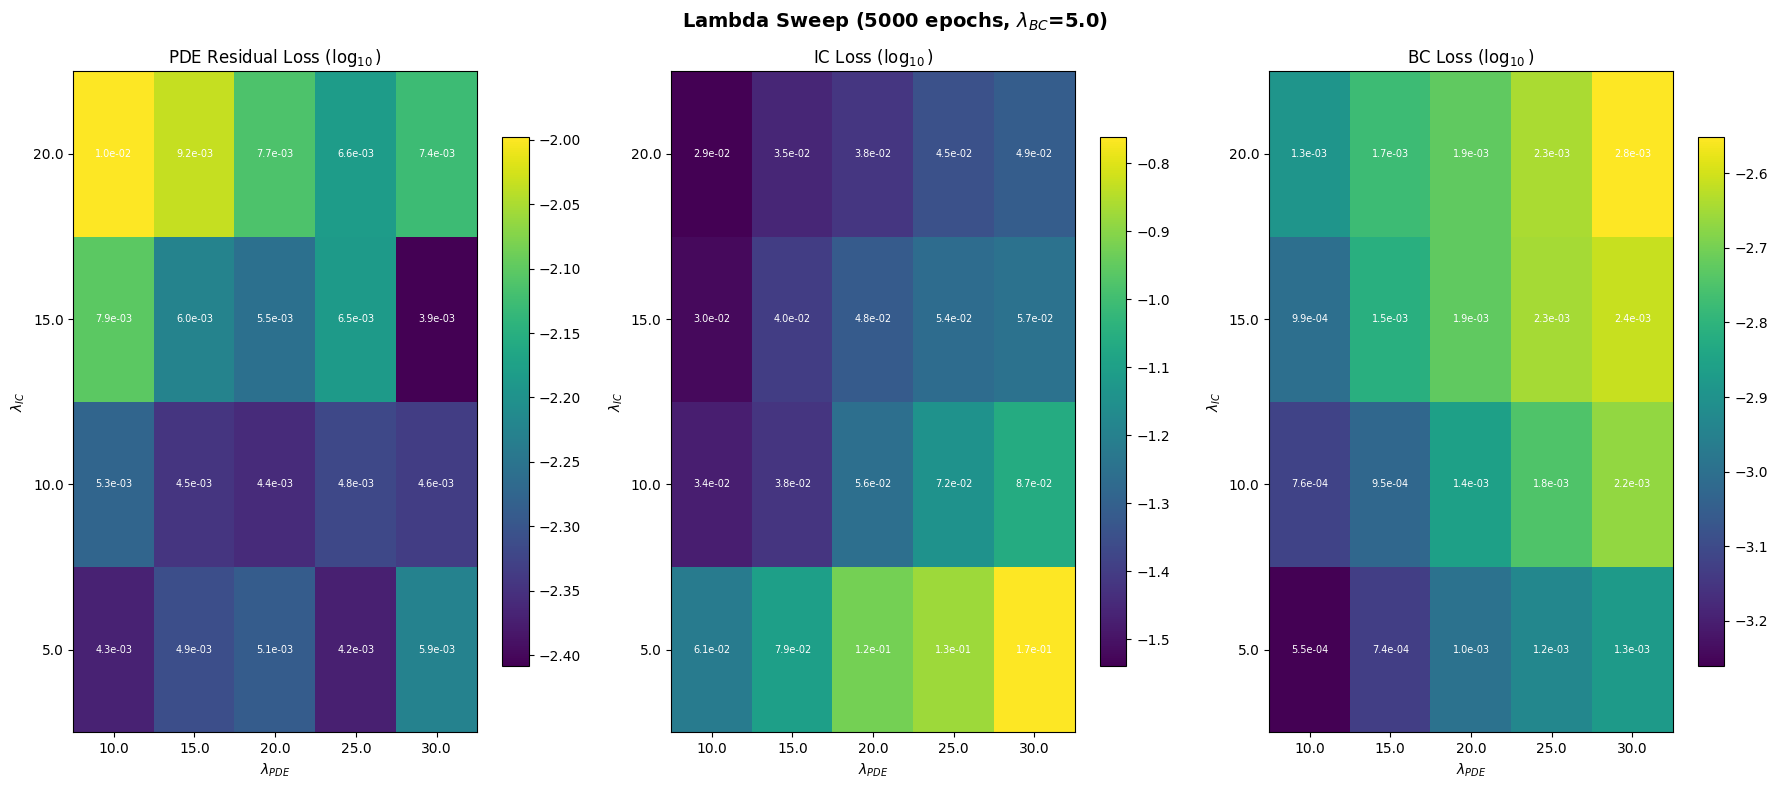

In [17]:
# Initiating the heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 8))


for ax, metric, title in zip(axes,
  ['pde_loss', 'ic_loss', 'bc_loss'],
  ['PDE Residual Loss', 'IC Loss', 'BC Loss']):
  pivot = df_sweep.pivot_table(index='lambda_ic', columns='lambda_pde', values=metric)
  log_vals = np.log10(pivot.values)
  im = ax.imshow(log_vals, cmap='viridis', aspect='auto', origin='lower')
  ax.set_xticks(range(len(LAMBDA_PDE_VALUES)))
  ax.set_xticklabels(LAMBDA_PDE_VALUES)
  ax.set_yticks(range(len(LAMBDA_IC_VALUES)))
  ax.set_yticklabels(LAMBDA_IC_VALUES)
  ax.set_xlabel('$\\lambda_{PDE}$')
  ax.set_ylabel('$\\lambda_{IC}$')
  ax.set_title(f'{title} ($\\log_{{10}}$)')
  fig.colorbar(im, ax=ax, shrink=0.8)
  for i in range(len(LAMBDA_IC_VALUES)):
      for j in range(len(LAMBDA_PDE_VALUES)):
          ax.text(j, i, f'{pivot.values[i, j]:.1e}',
                  ha='center', va='center', fontsize=7, color='white')
plt.suptitle(f'Lambda Sweep ({SWEEP_EPOCHS} epochs, $\\lambda_{{BC}}$={LAMBDA_BC_FIXED})',
           fontweight='bold', fontsize=14)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_dir / "hyper_bs_heatmap.pdf", bbox_inches="tight")
plt.show()

### Ranked by PDE Loss

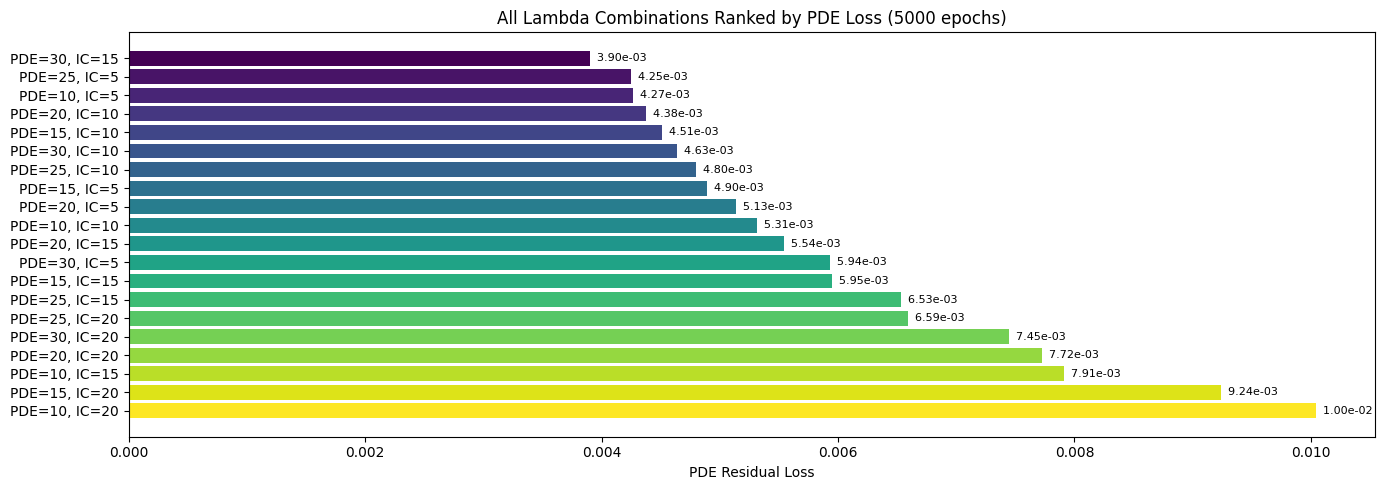

In [18]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
labels = [f"PDE={r.lambda_pde:.0f}, IC={r.lambda_ic:.0f}"
          for _, r in df_ranked.iterrows()]

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ranked)))
bars = ax.barh(range(len(df_ranked)), df_ranked['pde_loss'], color=colors)
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels(labels)
ax.set_xlabel('PDE Residual Loss')
ax.set_title(f'All Lambda Combinations Ranked by PDE Loss ({SWEEP_EPOCHS} epochs)')
ax.invert_yaxis()

for i, v in enumerate(df_ranked['pde_loss']):
    ax.text(v, i, f'  {v:.2e}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_ranked.pdf", bbox_inches="tight")
plt.show()

### Top 3 Loss Curves

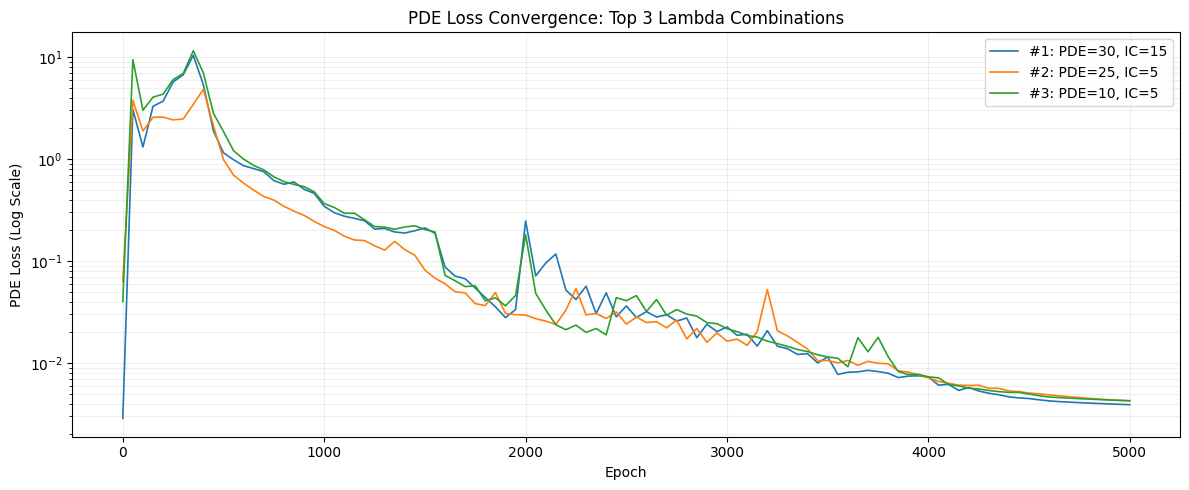

In [19]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
top_3_indices = df_ranked.head(3).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))

for rank, idx in enumerate(top_3_indices):
    r = sweep_results[idx] if idx < len(sweep_results) else None
    for orig in sweep_results:
        if (orig['lambda_pde'] == df_ranked.loc[idx, 'lambda_pde'] and
            orig['lambda_ic'] == df_ranked.loc[idx, 'lambda_ic']):
            r = orig
            break

    label = f"#{rank+1}: PDE={r['lambda_pde']:.0f}, IC={r['lambda_ic']:.0f}"
    ax.plot(r['history']['epoch'], r['history']['pde'], label=label, lw=1.2)

ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('PDE Loss (Log Scale)')
ax.set_title('PDE Loss Convergence: Top 3 Lambda Combinations')
ax.legend()
ax.grid(True, which='both', ls='-', alpha=0.2)
plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_top3_curves.pdf", bbox_inches="tight")
plt.show()

In [20]:
### Download the plots again from Colab

In [21]:
if IN_COLAB:
    print(f"Plots already saved to Google Drive: {out_dir}")
else:
    print(f"PDFs saved locally to: {out_dir.resolve()}")

Plots already saved to Google Drive: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda
